# AerisPlane — Full Discipline Chain

This notebook walks through a complete MDO-ready analysis of a fixed-wing RC aircraft,
running all six discipline modules in sequence:

1. **Weights** — component mass buildup and CG
2. **Aerodynamics** — VLM lift and drag
3. **Stability** — static margin and stability derivatives
4. **Control** — roll rate and servo authority
5. **Mission** — energy budget for climb + cruise
6. **Structures** — wing beam loads, deflection, and margins of safety

The same aircraft definition is used throughout, and results from earlier disciplines
are passed directly to later ones — exactly as an MDO loop would do it.

## 0. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import aerisplane as ap
from aerisplane.catalog.materials import carbon_fiber_tube, petg

import aerisplane.weights as wts
import aerisplane.aero as aero
import aerisplane.stability as stab
import aerisplane.control as ctrl
import aerisplane.mission as mis
import aerisplane.structures as struc
from aerisplane.mission.segments import Mission, Climb, Cruise

## 1. Aircraft Definition

A conventional tractor trainer: rectangular NACA 2412 main wing (AR ≈ 7.5),
symmetric tapered H-tail with elevator, vertical tail with rudder,
simple fuselage, brushless motor + 4S LiPo, and a small camera payload.

In [4]:
# Structural components reused across surfaces
cf_spar = ap.Spar(
    position=0.25,
    material=carbon_fiber_tube,
    section=ap.TubeSection(outer_diameter=0.020, wall_thickness=0.002),
)
petg_skin = ap.Skin(material=petg, thickness=0.8e-3)
thin_skin  = ap.Skin(material=petg, thickness=0.5e-3)
small_spar = ap.Spar(
    position=0.25,
    material=carbon_fiber_tube,
    section=ap.TubeSection(outer_diameter=0.010, wall_thickness=0.001),
)

main_wing = ap.Wing(
    name="main_wing",
    xsecs=[
        ap.WingXSec(xyz_le=[0.10, 0.00, 0.0], chord=0.20,
                    airfoil=ap.Airfoil.from_naca("2412"),
                    spar=cf_spar, skin=petg_skin, twist=0.0),
        ap.WingXSec(xyz_le=[0.10, 0.75, 0.0], chord=0.20,
                    airfoil=ap.Airfoil.from_naca("2412"),
                    spar=cf_spar, skin=petg_skin, twist=-2.0),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(
            name="aileron", span_start=0.5, span_end=0.9,
            chord_fraction=0.25, symmetric=False,
            servo=ap.Servo(name="ail_servo", torque=2.5, speed=300.0,
                           voltage=5.0, mass=0.018),
        ),
    ],
)

htail = ap.Wing(
    name="htail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.75, 0.00, 0.0], chord=0.12,
                    spar=small_spar, skin=thin_skin),
        ap.WingXSec(xyz_le=[0.75, 0.30, 0.0], chord=0.08,
                    spar=small_spar, skin=thin_skin),
    ],
    symmetric=True,
    control_surfaces=[
        ap.ControlSurface(
            name="elevator", span_start=0.1, span_end=0.9,
            chord_fraction=0.30,
            servo=ap.Servo(name="elev_servo", torque=3.0, speed=300.0,
                           voltage=6.0, mass=0.024),
        ),
    ],
)

# Vertical tail: span runs in Z (vertical), not Y
vtail = ap.Wing(
    name="vtail",
    xsecs=[
        ap.WingXSec(xyz_le=[0.75, 0.0, 0.00], chord=0.10),
        ap.WingXSec(xyz_le=[0.75, 0.0, 0.20], chord=0.06),
    ],
    symmetric=False,
    control_surfaces=[
        ap.ControlSurface(
            name="rudder", span_start=0.1, span_end=0.9,
            chord_fraction=0.35,
            servo=ap.Servo(name="rud_servo", torque=3.0, speed=300.0,
                           voltage=6.0, mass=0.024),
        ),
    ],
)

fuselage = ap.Fuselage(
    name="fuselage",
    xsecs=[
        ap.FuselageXSec(x=0.00, radius=0.020),
        ap.FuselageXSec(x=0.12, radius=0.055),
        ap.FuselageXSec(x=0.60, radius=0.055),
        ap.FuselageXSec(x=0.85, radius=0.020),
    ],
    material=petg,
    wall_thickness=0.001,
)

propulsion = ap.PropulsionSystem(
    motor=ap.Motor(name="motor", kv=1100, resistance=0.028,
                   no_load_current=1.2, max_current=40.0, mass=0.120),
    propeller=ap.Propeller(diameter=0.254, pitch=0.127, mass=0.030),
    battery=ap.Battery(name="4S2200", capacity_ah=2.2, nominal_voltage=14.8,
                       cell_count=4, c_rating=30.0, mass=0.195),
    esc=ap.ESC(name="esc", max_current=40.0, mass=0.030),
    position=np.array([0.0, 0.0, 0.0]),
)

aircraft = ap.Aircraft(
    name="TutorialTrainer",
    wings=[main_wing, htail, vtail],
    fuselages=[fuselage],
    propulsion=propulsion,
    payload=ap.Payload(mass=0.100, cg=np.array([0.25, 0.0, 0.0]), name="payload"),
    xyz_ref=[0.15, 0.0, 0.0],
)

cruise = ap.FlightCondition(velocity=15.0, altitude=100.0, alpha=3.0, beta=0.0)

print(f"Reference area:  {aircraft.reference_area():.4f} m²")
print(f"Main wing span:  {main_wing.semispan() * 2:.2f} m")
print(f"Main wing AR:    {main_wing.aspect_ratio():.2f}")

Reference area:  0.3000 m²
Main wing span:  1.50 m
Main wing AR:    7.50


## 2. Weights

Component mass buildup from geometry + hardware catalog.

In [5]:
weight_result = wts.analyze(aircraft)
print(weight_result.report())

AerisPlane Weight Buildup
Component                 Mass [g]  CG_x [mm]  CG_z [mm] Source         %
---------------------------------------------------------------------------
main_wing_skin               609.6      180.0        0.0 computed    27.8
fuselage_shell               321.4      411.4        0.0 computed    14.6
main_wing_spar               271.4      150.0        0.0 computed    12.4
main_wing_ribs               229.9      180.0        0.0 computed    10.5
battery                      195.0        0.0        0.0 computed     8.9
motor                        120.0        0.0        0.0 computed     5.5
payload                      100.0      250.0        0.0 computed     4.6
htail_skin                    76.2      790.0        0.0 computed     3.5
fasteners                     54.0      556.7       11.1 computed     2.5
propeller                     30.0        0.0        0.0 computed     1.4
esc                           30.0        0.0        0.0 computed     1.4
htail_spar

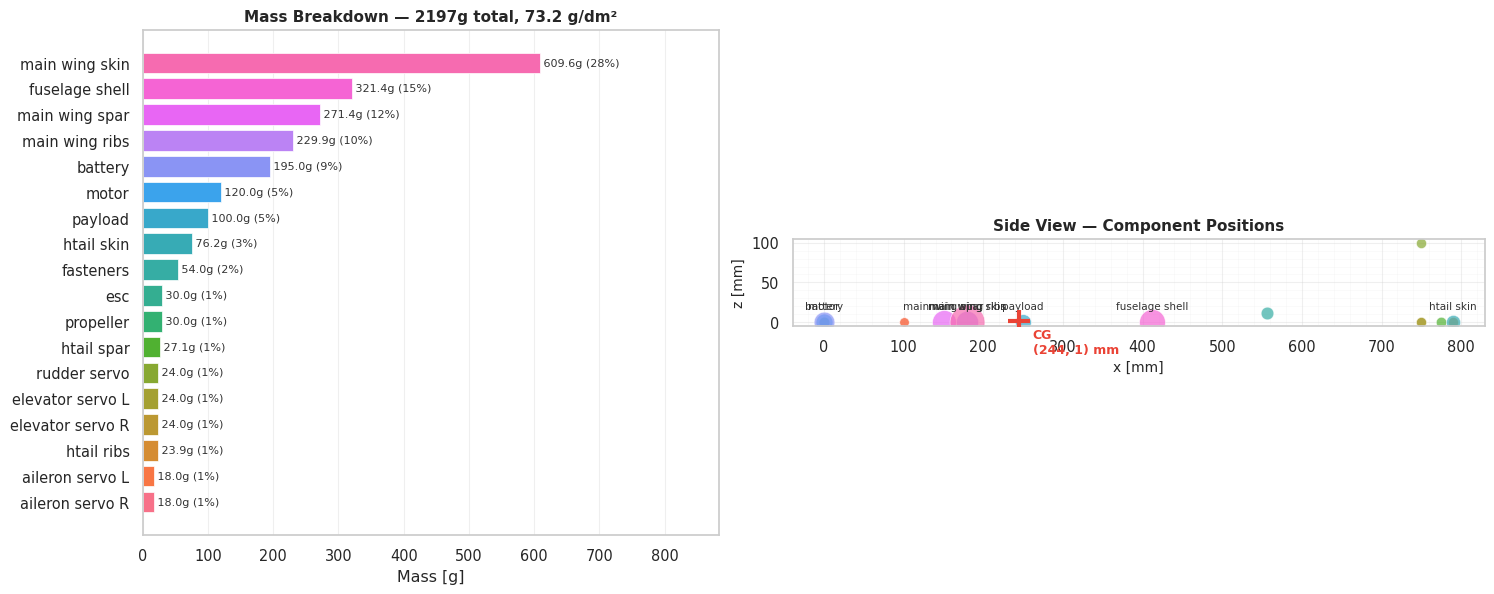

In [6]:
# Mass breakdown pie chart
weight_result.plot()
plt.show()

## 3. Aerodynamics

VLM analysis at the cruise condition, then a CL–α sweep to build a polar.

In [10]:
aero_result = aero.analyze(aircraft, cruise, method="lifting_line")
aero_result.report()

print(f"CL = {aero_result.CL:.4f}")
print(f"CD = {aero_result.CD:.4f}")
print(f"L/D = {aero_result.CL / aero_result.CD:.1f}")
print(f"L = {aero_result.L:.1f} N   (weight = {weight_result.total_mass * 9.81:.1f} N)")

----------------------------------------------------
  AeroResult — method: lifting_line
----------------------------------------------------
  Operating point:
    alpha          =     3.0000  deg
    beta           =     0.0000  deg
    velocity       =    15.0000  m/s
    altitude       =      100.0  m
    dyn. pressure  =     136.49  Pa
    Reynolds (MAC) =     203777
----------------------------------------------------
  Reference geometry:
    S_ref = 0.3000 m^2   c_ref = 0.2000 m   b_ref = 1.5000 m
----------------------------------------------------
  Force coefficients (wind axes):
    CL   =   0.493313
    CD   =   0.026612
    CY   =  -0.000000
----------------------------------------------------
  Moment coefficients (body axes):
    Cl   =   0.000000  (roll)
    Cm   =  -0.300885  (pitch)
    Cn   =   0.000000  (yaw)
----------------------------------------------------
  Forces (wind axes):
    L    =     20.200  N
    D    =      1.090  N
    Y    =     -0.000  N
--------

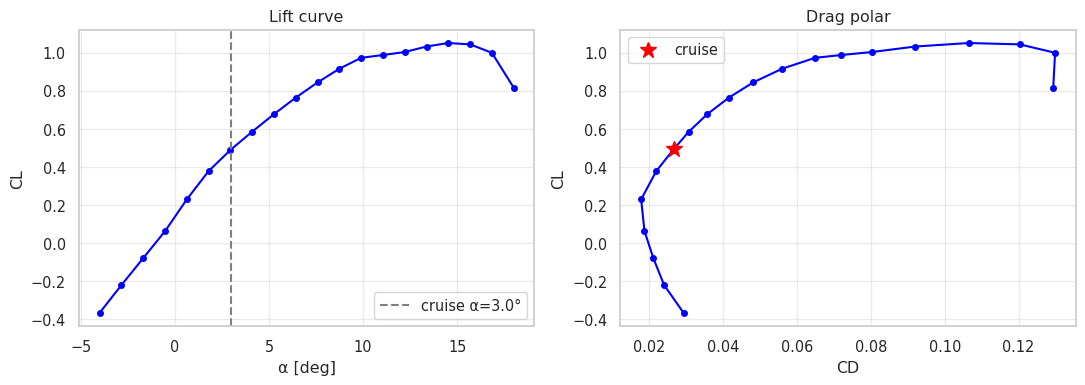

In [ ]:
# CL-alpha and CL-CD polar sweep
alphas = np.linspace(-4, 18, 20)
polar_results = [
    aero.analyze(aircraft, ap.FlightCondition(velocity=15.0, altitude=100.0, alpha=a), method="lifting_line")
    for a in alphas
]

CLs = [r.CL for r in polar_results]
CDs = [r.CD for r in polar_results]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(alphas, CLs, "b-o", ms=4)
axes[0].axvline(cruise.alpha, ls="--", color="gray", label=f"cruise α={cruise.alpha}°")
axes[0].set_xlabel("α [deg]")
axes[0].set_ylabel("CL")
axes[0].set_title("Lift curve")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(CDs, CLs, "b-o", ms=4)
axes[1].plot(aero_result.CD, aero_result.CL, "r*", ms=12, label="cruise")
axes[1].set_xlabel("CD")
axes[1].set_ylabel("CL")
axes[1].set_title("Drag polar")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Stability

Numerical stability derivatives via central finite differences (5 aero calls).
Key output: **static margin** (positive = stable) and **CL_alpha**.

In [7]:
stab_result = stab.analyze(aircraft, cruise, weight_result)
print(stab_result.report())

AerisPlane Stability Analysis

Longitudinal Static Stability
----------------------------------------
  CL_alpha          +0.09329  1/deg
  Cm_alpha          -0.10296  1/deg
  Neutral point        465.1  mm from nose
  CG position          244.4  mm from nose
  Static margin        110.4  % MAC
  Status              STABLE

Lateral-Directional Static Stability
----------------------------------------
  Cl_beta           +0.00095  1/deg
  Cn_beta           +0.00209  1/deg
  Dihedral effect  WARN (positive)
  Weathercock        OK (positive)

Trim
----------------------------------------
  Trim alpha           -0.59  deg
  Trim elevator         0.01  deg

Tail Volume Coefficients
----------------------------------------
  Vh                   0.626
  Vv                   0.000

CG Envelope (fraction of MAC from LE)
----------------------------------------
  Forward limit         67.2  % MAC
  Aft limit            177.6  % MAC
  Current CG            72.2  % MAC

Baseline Coefficients
---

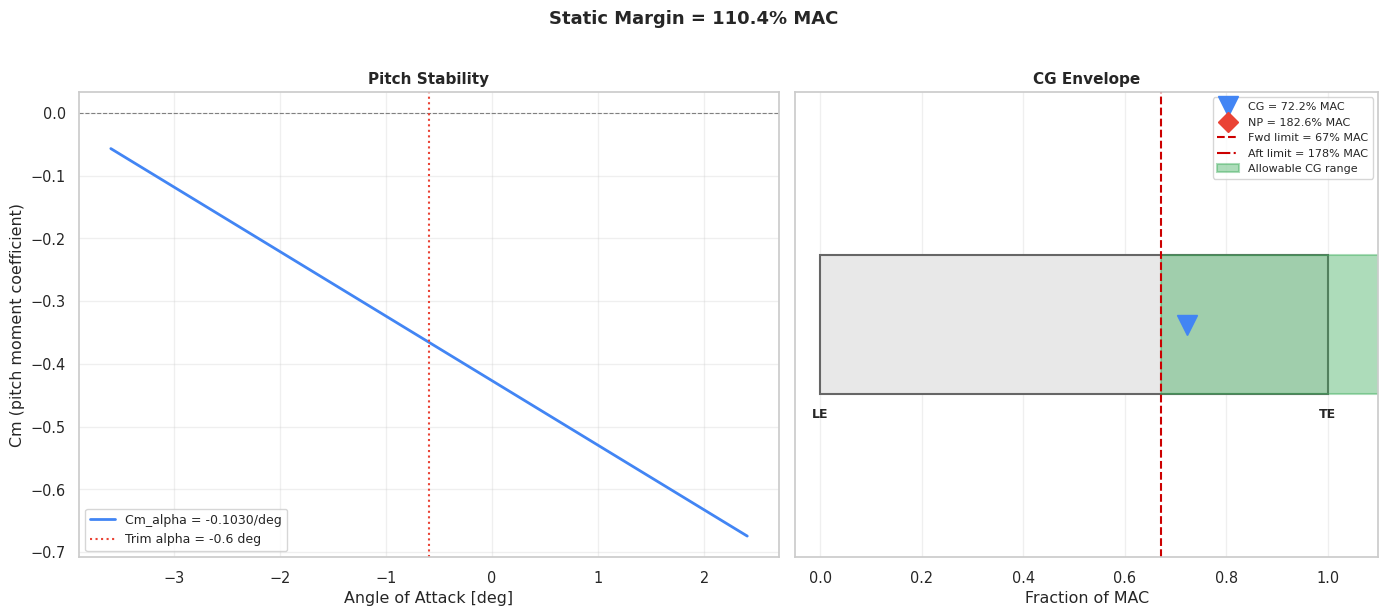

In [8]:
# Stability plot: Cm-alpha and CG envelope
stab_result.plot()
plt.show()

## 5. Control

Roll rate from aileron authority and servo loads.

In [9]:
ctrl_result = ctrl.analyze(aircraft, cruise, weight_result, stab_result)
print(ctrl_result.report())

AerisPlane Control Authority Analysis

Control Derivatives
----------------------------------------
  Cl_delta_a        -0.00354  1/deg
  Cm_delta_e        -0.03997  1/deg
  Cn_delta_r        +0.00000  1/deg

Roll Authority
----------------------------------------
  Max roll rate         64.7  deg/s
  Authority             0.36  (1.0 = 180 deg/s)
  Status          INSUFFICIENT

Pitch Authority
----------------------------------------
  Max pitch accel     4718.1  deg/s^2
  Authority             0.97
  Status            MARGINAL

Yaw / Crosswind Authority
----------------------------------------
  Max crosswind          0.0  m/s
  Authority             0.00  (1.0 = 5 m/s)
  Status          INSUFFICIENT

Servo Loads
----------------------------------------
  Aileron       hinge = 0.027 N*m, margin = 93.28x  [OK]
  Elevator      hinge = 0.008 N*m, margin = 388.68x  [OK]
  Rudder        hinge = 0.000 N*m, margin = infx  [OK]


## 6. Mission

Energy budget for a simple climb-then-cruise mission.

In [10]:
mission = Mission(segments=[
    Climb(to_altitude=100.0, climb_rate=2.0, velocity=12.0),
    Cruise(distance=1500.0, velocity=15.0, altitude=100.0),
])

mis_result = mis.analyze(aircraft, weight_result, mission)
print(mis_result.report())

# Battery capacity check
battery_energy_wh = aircraft.propulsion.battery.energy() / 3600
used_wh = mis_result.total_energy / 3600
print(f"\nBattery capacity: {battery_energy_wh:.1f} Wh")
print(f"Mission uses:     {used_wh:.1f} Wh  ({used_wh / battery_energy_wh * 100:.0f}%)")

AerisPlane Mission Analysis

Segment          Duration  Distance    Energy  Avg Power        Alt
---------------------------------------------------------------------------
climb                 50s      600m      5.5Wh     395.2W    0->100m
cruise               100s     1500m      3.2Wh     114.3W  100->100m
---------------------------------------------------------------------------
TOTAL                150s     2100m      8.7Wh

Battery energy:   32.6 Wh
Energy used:      8.7 Wh
Energy margin:    73.4%
Mission time:     2.5 min
Status:           FEASIBLE

Battery capacity: 32.6 Wh
Mission uses:     8.7 Wh  (27%)


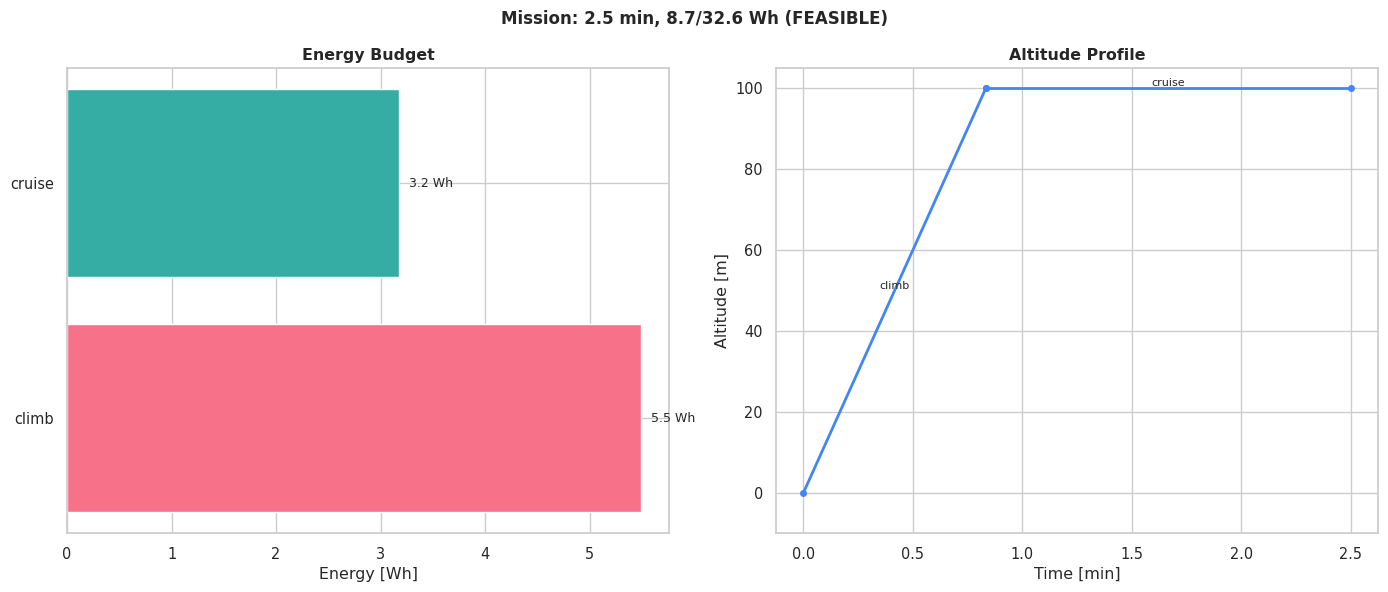

In [11]:
# Mission energy plot
mis_result.plot()
plt.show()

## 7. Structures

Euler-Bernoulli beam analysis of the main wing at the design load factor
(max of 3.5g maneuver and CS-VLA gust case, × 1.5 safety factor).

EI is computed from the actual airfoil geometry using the transformed-section method
(spar tube + PETG skin).

In [12]:
struct_result = struc.analyze(
    aircraft, aero_result, weight_result,
    stability_result=stab_result,   # uses CL_alpha for gust load factor
    n_limit=3.5,
    safety_factor=1.5,
)
print(struct_result.report())

Structural Analysis
Design load factor: 10.64 g (ultimate)
Overall: SAFE

Wing: main_wing
  Design load factor:   10.64 g (ultimate)
  Root bending moment:  1.73 N*m
  Root shear force:     13.69 N
  Tip deflection:       0.0 mm  (0.0% semispan)
  Bending MoS (root):   +401.731  PASS
  Shear MoS (root):     +7152.930  PASS
  Buckling MoS (root):  +4348.497  PASS
  Spar fits in airfoil: PASS
  Divergence speed:     inf (no risk)
  Overall: SAFE
Wing: htail
  Design load factor:   10.64 g (ultimate)
  Root bending moment:  0.75 N*m
  Root shear force:     6.54 N
  Tip deflection:       0.3 mm  (0.1% semispan)
  Bending MoS (root):   +115.176  PASS
  Shear MoS (root):     +3742.356  PASS
  Buckling MoS (root):  +1253.699  PASS
  Spar fits in airfoil: PASS
  Divergence speed:     inf (no risk)
  Overall: SAFE


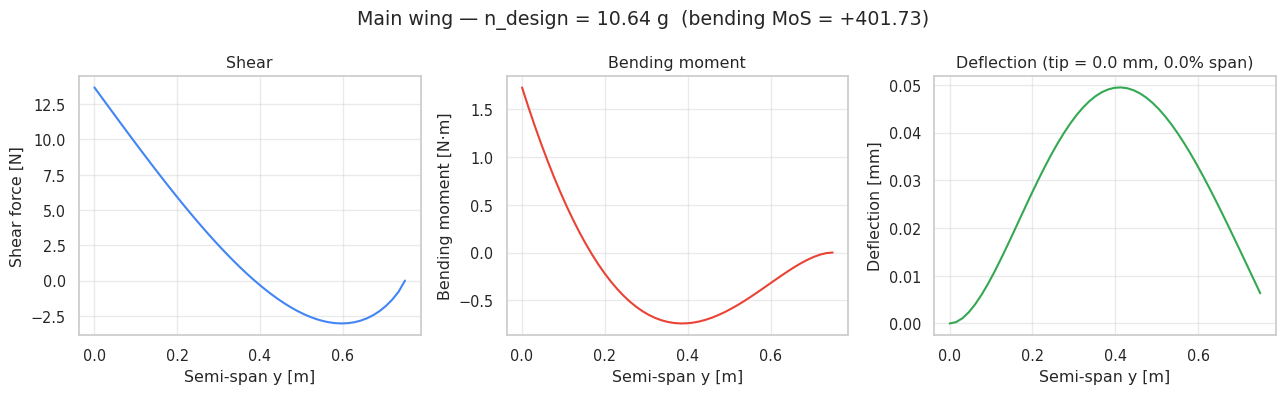

In [13]:
# Spanwise shear, bending moment, and deflection for the main wing
wing_r = next(w for w in struct_result.wings if w.wing_name == "main_wing")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(
    f"Main wing — n_design = {struct_result.design_load_factor:.2f} g  "
    f"(bending MoS = {wing_r.bending_margin:+.2f})"
)

y = wing_r.y

axes[0].plot(y, wing_r.shear_force, "C0")
axes[0].set_xlabel("Semi-span y [m]")
axes[0].set_ylabel("Shear force [N]")
axes[0].set_title("Shear")
axes[0].grid(True, alpha=0.4)

axes[1].plot(y, wing_r.bending_moment, "C1")
axes[1].set_xlabel("Semi-span y [m]")
axes[1].set_ylabel("Bending moment [N·m]")
axes[1].set_title("Bending moment")
axes[1].grid(True, alpha=0.4)

axes[2].plot(y, wing_r.deflection * 1000, "C2")
axes[2].set_xlabel("Semi-span y [m]")
axes[2].set_ylabel("Deflection [mm]")
axes[2].set_title(f"Deflection (tip = {wing_r.tip_deflection * 1000:.1f} mm, "
                  f"{wing_r.tip_deflection_ratio * 100:.1f}% span)")
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## 8. Summary

Collect the key numbers from all six disciplines into one table.

In [14]:
W = weight_result.total_mass * 9.81
L = aero_result.L

print("=" * 55)
print(f"{'FULL DISCIPLINE CHAIN SUMMARY':^55}")
print("=" * 55)
print()
print("WEIGHTS")
print(f"  Total mass:         {weight_result.total_mass * 1000:.0f} g")
print(f"  CG (x):             {weight_result.cg[0] * 1000:.1f} mm from nose")
print()
print(f"AERODYNAMICS  (α={cruise.alpha}°, V={cruise.velocity} m/s)")
print(f"  CL:                 {aero_result.CL:.4f}")
print(f"  CD:                 {aero_result.CD:.4f}")
print(f"  L/D:                {aero_result.CL / aero_result.CD:.1f}")
print(f"  Lift / Weight:      {L / W:.2f}")
print()
print("STABILITY")
print(f"  Static margin:      {stab_result.static_margin * 100:.1f}% MAC")
print(f"  CL_alpha:           {stab_result.CL_alpha:.4f} 1/deg")
print()
print("CONTROL")
print(f"  Max roll rate:      {ctrl_result.max_roll_rate:.1f} deg/s")
print()
print("MISSION  (climb 100m + cruise 1.5 km)")
print(f"  Total time:         {mis_result.total_time / 60:.1f} min")
print(f"  Total distance:     {mis_result.total_distance:.0f} m")
print(f"  Energy consumed:    {mis_result.total_energy / 3600:.1f} Wh")
print()
print("STRUCTURES  (main wing)")
print(f"  Design load factor: {struct_result.design_load_factor:.2f} g")
print(f"  Root moment:        {wing_r.root_bending_moment:.1f} N·m")
print(f"  Tip deflection:     {wing_r.tip_deflection * 1000:.1f} mm  ({wing_r.tip_deflection_ratio * 100:.1f}% span)")
print(f"  Bending MoS:        {wing_r.bending_margin:+.3f}  {'PASS' if wing_r.bending_margin >= 0 else 'FAIL'}")
print(f"  Shear MoS:          {wing_r.shear_margin:+.3f}  {'PASS' if wing_r.shear_margin >= 0 else 'FAIL'}")
print(f"  Buckling MoS:       {wing_r.buckling_margin:+.3f}  {'PASS' if wing_r.buckling_margin >= 0 else 'FAIL'}")
print(f"  Overall:            {'SAFE' if struct_result.is_safe else 'FAILED'}")
print("=" * 55)

             FULL DISCIPLINE CHAIN SUMMARY             

WEIGHTS
  Total mass:         2197 g
  CG (x):             244.4 mm from nose

AERODYNAMICS  (α=3.0°, V=15.0 m/s)
  CL:                 0.3291
  CD:                 0.0044
  L/D:                74.2
  Lift / Weight:      0.63

STABILITY
  Static margin:      110.4% MAC
  CL_alpha:           0.0933 1/deg

CONTROL
  Max roll rate:      64.7 deg/s

MISSION  (climb 100m + cruise 1.5 km)
  Total time:         2.5 min
  Total distance:     2100 m
  Energy consumed:    8.7 Wh

STRUCTURES  (main wing)
  Design load factor: 10.64 g
  Root moment:        1.7 N·m
  Tip deflection:     0.0 mm  (0.0% span)
  Bending MoS:        +401.731  PASS
  Shear MoS:          +7152.930  PASS
  Buckling MoS:       +4348.497  PASS
  Overall:            SAFE
